# 04 · Fraud Explainability (SHAP)

**Why SHAP?** It gives each feature a contribution to *one specific prediction*, and the contributions provably add up to the model's output. That makes it suitable for an analyst-facing "why was this flagged?" view. Alternatives:
- XGBoost's built-in feature importance is global only, and depends on the importance type.
- Permutation importance is also global only.
- LIME approximates the model locally rather than exactly.

For tree models, `TreeExplainer` computes SHAP values exactly and fast.

SHAP values are in **log-odds** (the model's raw output). Positive = pushes towards fraud.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src import evaluation as ev
from src import fraud_model as fm
from src.feature_engineering import FEATURE_SETS

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})
MODEL_COLORS = {"logistic_regression": "#2a78d6", "random_forest": "#eb6834", "xgboost": "#1baf7a"}

from src import explainability as xai
bundle = fm.load_bundle()
validation = fm.load_split_frame("validation")
print("Explaining:", bundle["version"])

Explaining: fraud-xgboost-full-20261001


## 1. Global importance
Mean |SHAP| over a stratified sample of validation transactions: all frauds plus 20,000 legitimate ones, so fraud behaviour is represented.

,feature,mean_abs_shap,label
0,orig_fully_drained,5.9067,Sender account fully drained
1,log_old_balance_dest,3.9892,Recipient balance before
2,log_new_balance_dest,3.2450,Recipient balance after
3,orig_balance_error,3.2403,Sender balance inconsistency
4,log_amount_to_orig_balance,3.0161,Amount relative to sender balance
5,log_amount,2.7314,Transaction amount
6,dest_balance_error,1.6134,Recipient balance inconsistency
7,is_transfer,0.5198,Transaction type
8,orig_zero_before,0.3213,Sender started with zero balance
9,log_old_balance_orig,0.2990,Sender balance before


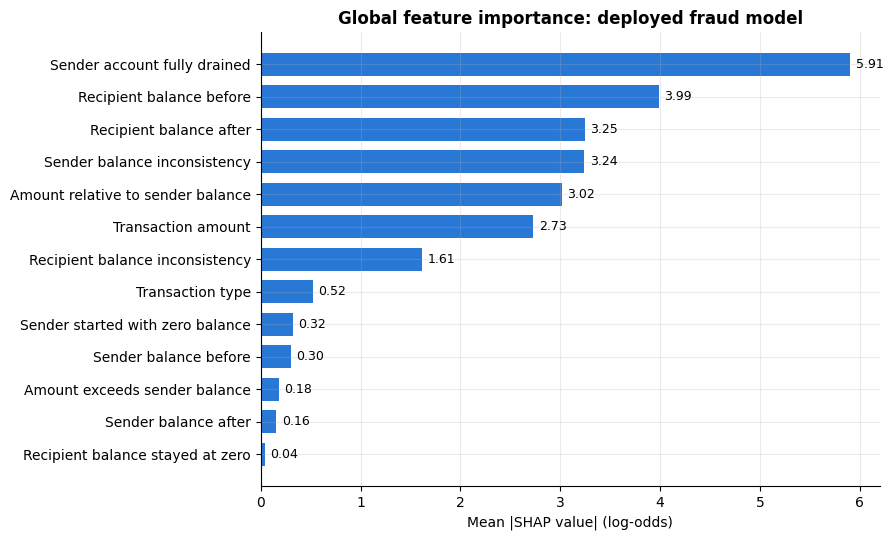

In [2]:
sample = pd.concat([
    validation[validation["is_fraud"] == 1],
    validation[validation["is_fraud"] == 0].sample(20_000, random_state=42),
])
importance = xai.global_importance(bundle, sample)
display(importance)

plot = importance.sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(plot["label"], plot["mean_abs_shap"], color="#2a78d6", height=0.7)
for y, v in enumerate(plot["mean_abs_shap"]):
    ax.annotate(f"{v:.2f}", (v, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xlabel("Mean |SHAP value| (log-odds)")
ax.set_title("Global feature importance: deployed fraud model")
plt.tight_layout(); plt.show()

> **Finding:**
> - `orig_fully_drained` is the single most influential feature (mean |SHAP| 5.91), confirming the model relies on the simulator's "empty the account" pattern.
> - The next most influential are the **recipient's balances** (3.99 and 3.25), ahead of sender balance inconsistency (3.24), amount-to-balance ratio (3.02) and amount (2.73).
> - `dest_zero_before_and_after` contributes almost nothing (0.04). It was strong on its own (notebook 02), but the log recipient-balance features already carry the same information, so the model uses those instead.

## 2. Direction of effects
SHAP summary (beeswarm): each dot is one transaction. Red = high feature value, blue = low. Position = effect on the fraud score.

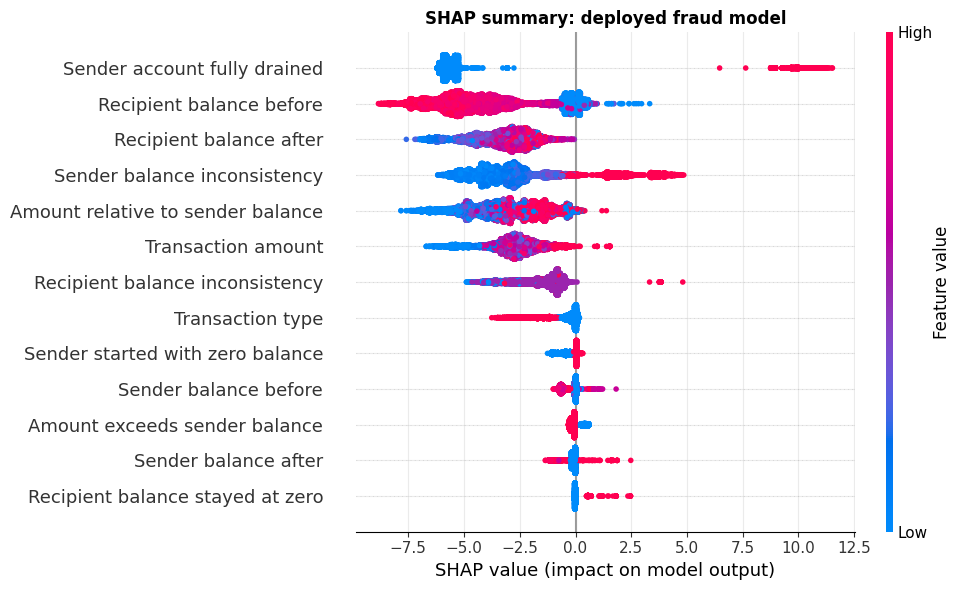

In [3]:
import shap
values, base = xai.shap_values(bundle, sample[bundle["features"]])
shap.summary_plot(values, sample[bundle["features"]].rename(columns=xai.FEATURE_LABELS), show=False, plot_size=(10, 6))
plt.title("SHAP summary: deployed fraud model", fontweight="bold")
plt.tight_layout(); plt.show()

> **Finding:**
> - **Draining the sender account** (red, right) pushes strongly towards fraud (+6 to +11 log-odds). Not draining it pushes strongly against (about −5).
> - **A high recipient balance before the transaction pushes towards legitimate.** Fraud tends to land in empty mule-like accounts.
> - **Counter-intuitive:** `Transaction type` = TRANSFER (red) pushes slightly *away* from fraud, even though TRANSFER has the higher raw fraud rate (notebook 01). SHAP shows a feature's effect *given all the other features*. Once balances are known, being a TRANSFER adds no extra risk. This is a good example of why SHAP explanations differ from simple correlations.

## 3. Local explanations
Three real validation transactions: a caught fraud, the highest-scoring legitimate transaction (a false alarm), and a missed fraud (the lowest-scoring fraud).

In [4]:
from src.preprocessing import format_transaction_id, load_clean_transactions

raw = load_clean_transactions().set_index("transaction_id")
val_scores = bundle["model"].predict_proba(validation[bundle["features"]])[:, 1]
validation = validation.assign(score=val_scores)

picks = {
    "Caught fraud (median-scoring fraud)": validation[validation.is_fraud == 1].sort_values("score").iloc[len(validation[validation.is_fraud == 1]) // 2],
    "False alarm (highest-scoring legitimate)": validation[validation.is_fraud == 0].sort_values("score").iloc[-1],
    "Missed fraud (lowest-scoring fraud)": validation[validation.is_fraud == 1].sort_values("score").iloc[0],
}

def show_case(title, row):
    tx = raw.loc[int(row["transaction_id"])].to_dict()
    pred = fm.predict_transaction(bundle, tx)
    exp = xai.explain_transaction(bundle, tx, top_n=5)
    print(f"=== {title}")
    print(f"Transaction ID: {format_transaction_id(int(row['transaction_id']))}  |  actual: {'FRAUD' if row['is_fraud'] else 'legitimate'}")
    print(f"Fraud score: {pred['fraud_probability']:.2%}  |  Risk level: {pred['risk_level']}")
    print("Main contributing factors (SHAP, log-odds):")
    for f in exp["top_factors"]:
        print(f"  {f['shap_value']:+7.2f}  {f['label']:<36} ({f['value_description']})")
    shown = sum(f["shap_value"] for f in exp["top_factors"])
    others = exp["model_output_log_odds"] - exp["base_value"] - shown
    print(f"  {others:+7.2f}  (all other features combined)")
    print(f"  base value {exp['base_value']:+.2f}  ->  model output {exp['model_output_log_odds']:+.2f} log-odds")
    print()

for title, row in picks.items():
    show_case(title, row)

=== Caught fraud (median-scoring fraud)
Transaction ID: TX-6259966  |  actual: FRAUD
Fraud score: 100.00%  |  Risk level: HIGH
Main contributing factors (SHAP, log-odds):
   +10.48  Sender account fully drained         (entire sender balance moved: yes)
    +4.27  Sender balance inconsistency         (sender balance changed by 1,026,684.46 vs amount 1,026,684.46)
    -1.98  Recipient balance before             (recipient balance before 59,926.13)
    -1.90  Recipient balance after              (recipient balance after 1,086,610.59)
    -1.48  Recipient balance inconsistency      (recipient balance changed by 1,026,684.46 vs amount 1,026,684.46)
    -1.90  (all other features combined)
  base value +8.83  ->  model output +16.32 log-odds

=== False alarm (highest-scoring legitimate)
Transaction ID: TX-3928776  |  actual: legitimate
Fraud score: 99.23%  |  Risk level: HIGH
Main contributing factors (SHAP, log-odds):
    -4.90  Sender account fully drained         (entire sender balance m

> **Finding:**
> - **Every explanation starts from a base value of +8.83 log-odds.** That is the average model output, already high because of class weighting. The factors move the score up or down from there, and base + factors equals the model output exactly (tested in `tests/test_models_and_evaluation.py`).
> - **Caught fraud (TX-6259966):** the sender's entire balance (1,026,684.46) was moved (+10.48), consistent with the simulator's fraud pattern.
> - **False alarm (TX-3928776):** a legitimate transfer of 506,942.41 from an account showing a zero balance. Nothing strongly *increases* its risk. It scores 99.23% mainly because the evidence against fraud (−4.90 for not draining the account) is not enough to pull it down from the high base value.
> - **Missed fraud (TX-0408956):** it looks exactly like a legitimate transaction. The amount (314,251.58) exceeds the sender's balance (75,956.47), the overspend pattern that is typical of legitimate PaySim customers, and the recipient already held 7.96M. The model cannot catch fraud that does not follow the simulator's fraud pattern.
>
> These are the structured facts the investigation assistant (Phase 10) receives. It rewords them; it cannot add reasons of its own.